## 1. Install Dependencies

In [2]:
!pip install mne --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 46.5 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


## 2. Imports

In [3]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mne
mne.set_log_level('WARNING')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version : 2.20.0
GPU available      : False


## 3. Download a Small Subset of Sleep-EDF Data

We download **2 subjects** (4 files total) from the Sleep Cassette portion of Sleep-EDF Expanded on PhysioNet.
Using the full dataset is NOT required.

In [6]:
DATA_DIR = Path('sleep_edf_data')
DATA_DIR.mkdir(exist_ok=True)

BASE_URL = "https://physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/"

FILES = [
    "SC4002E0-PSG.edf",
    "SC4002EC-Hypnogram.edf",
    "SC4011E0-PSG.edf",
    "SC4011EH-Hypnogram.edf",

]

for fname in FILES:
    dest = DATA_DIR / fname
    if not dest.exists():
        print(f'Downloading {fname} ...')
        urllib.request.urlretrieve(BASE_URL + fname, dest)
    else:
        print(f'Already downloaded: {fname}')

print('\nAll files ready.')


All files ready.


## 4. Data Loading and Segmentation

- **EEG channel:** Fpz-Cz (single channel only)
- **Epoch length:** 30 seconds per epoch (standard clinical unit)
- **Labels:** 5 classes — Wake=0, N1=1, N2=2, N3=3, REM=4

In [6]:
DATA_DIR = Path(r"D:\new study\sem2\DL\Assignment 4\sleep_edf_data")
# Map hypnogram annotation strings → integer class labels
STAGE_MAP = {
    'Sleep stage W': 0,   # Wake
    'Sleep stage 1': 1,   # N1
    'Sleep stage 2': 2,   # N2
    'Sleep stage 3': 3,   # N3
    'Sleep stage 4': 3,   # N3 (older R&K scoring merges stages 3 & 4)
    'Sleep stage R': 4,   # REM
}

STAGE_NAMES   = ['Wake', 'N1', 'N2', 'N3', 'REM']
EEG_CHANNEL   = 'EEG Fpz-Cz'
EPOCH_SEC     = 30


def load_subject(psg_path, hyp_path):

    raw   = mne.io.read_raw_edf(psg_path, include=[EEG_CHANNEL], preload=True)
    sfreq = int(raw.info['sfreq'])
    eeg   = raw.get_data(picks=[EEG_CHANNEL])[0]   # shape: (n_samples,)

    ann   = mne.read_annotations(hyp_path)

    samples_per_epoch = EPOCH_SEC * sfreq
    epochs, labels = [], []

    for onset, duration, description in zip(ann.onset, ann.duration, ann.description):
        if description not in STAGE_MAP:
            continue                          # skip Movement / Unscored

        label     = STAGE_MAP[description]
        n_epochs  = int(duration // EPOCH_SEC)
        start_smp = int(onset * sfreq)

        for i in range(n_epochs):
            s = start_smp + i * samples_per_epoch
            e = s + samples_per_epoch
            if e > len(eeg):
                break
            epochs.append(eeg[s:e])
            labels.append(label)

    return np.array(epochs, dtype=np.float32), np.array(labels, dtype=np.int32)


# Load both subjects
all_epochs, all_labels = [], []

subject_pairs = [
    (DATA_DIR / 'SC4002E0-PSG.edf', DATA_DIR / 'SC4002EC-Hypnogram.edf'),
    (DATA_DIR / 'SC4011E0-PSG.edf', DATA_DIR / 'SC4011EH-Hypnogram.edf'),
]

for psg, hyp in subject_pairs:
    e, l = load_subject(psg, hyp)
    print(f'{psg.name}: {len(e)} epochs')
    all_epochs.append(e)
    all_labels.append(l)

X = np.concatenate(all_epochs, axis=0)   # (N, 3000)
y = np.concatenate(all_labels, axis=0)   # (N,)

print(f'\nTotal epochs : {len(X)}')
print(f'Epoch length : {X.shape[1]} samples (= {X.shape[1]//100}s at 100 Hz)')
print(f'\nClass distribution:')
for i, name in enumerate(STAGE_NAMES):
    print(f'  {name:5s}: {np.sum(y == i):4d}')

FileNotFoundError: File does not exist: "/content/D:\new study\sem2\DL\Assignment 4\sleep_edf_data/SC4002E0-PSG.edf"

## 5. Preprocessing

- **Z-score normalization** per epoch (zero mean, unit variance)
- **Reshape** to `(N, timesteps, 1)` — Keras Conv1D expects `(batch, steps, channels)`
- **Stratified split:** 70% train / 15% val / 15% test

In [9]:
# Per-epoch z-score normalization
mean = X.mean(axis=1, keepdims=True)
std  = X.std(axis=1,  keepdims=True) + 1e-8
X_norm = (X - mean) / std

# Keras Conv1D input shape: (batch, timesteps, channels)
X_norm = X_norm[..., np.newaxis]   # (N, 3000, 1)

# Stratified 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 3941
Val   : 845
Test  : 845


## 6. TCN Model Architecture

A **Temporal Convolutional Network** uses:
- **Causal convolutions** — `padding='causal'` in Keras, so output at time *t* only sees inputs ≤ *t*
- **Dilated convolutions** — `dilation_rate` doubles each block (1 → 2 → 4 → 8) for a wide receptive field without many parameters
- **Residual connections** — skip connections stabilise training and help gradient flow

```
Input (3000, 1)
  └─ TCN Block (filters=32,  dilation=1)  → residual
  └─ TCN Block (filters=64,  dilation=2)  → residual
  └─ TCN Block (filters=64,  dilation=4)  → residual
  └─ TCN Block (filters=128, dilation=8)  → residual
  └─ GlobalAveragePooling1D
  └─ Dense(64, relu) → Dropout
  └─ Dense(5, softmax)   ← 5 sleep stages
```

In [10]:
def tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.2):
    residual = x

    # First causal-dilated conv
    x = layers.Conv1D(
        filters, kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation=None,
        kernel_initializer='he_normal'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Second causal-dilated conv
    x = layers.Conv1D(
        filters, kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation=None,
        kernel_initializer='he_normal'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Residual connection — 1x1 conv if channel dimensions differ
    if residual.shape[-1] != filters:
        residual = layers.Conv1D(filters, 1, padding='same')(residual)

    x = layers.Add()([x, residual])
    x = layers.ReLU()(x)
    return x


def build_tcn(input_shape=(3000, 1), num_classes=5,
              num_channels=None, kernel_size=7, dropout_rate=0.2):
    if num_channels is None:
        num_channels = [32, 64, 64, 128]

    inputs = keras.Input(shape=input_shape, name='eeg_input')
    x = inputs

    for i, filters in enumerate(num_channels):
        dilation = 2 ** i          # 1, 2, 4, 8
        x = tcn_block(x, filters, kernel_size, dilation, dropout_rate)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='sleep_stage')(x)

    model = Model(inputs, outputs, name='TCN_SleepStage')
    return model


model = build_tcn(input_shape=(X_train.shape[1], 1), num_classes=5)
model.summary()

Model: "TCN_SleepStage"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 3000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3000, 32)  │        256 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3000, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 3000, 32)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 3000, 32)  │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3000, 32)  │      7,200 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 32)  │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 3000, 32)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 3000, 32)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 3000, 32)  │         64 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 3000, 32)  │          0 │ dropout_1[0][0],  │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 3000, 32)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 3000, 64)  │     14,400 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 3000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 3000, 64)  │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 3000, 64)  │     28,736 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 64)  │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 3000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 3000, 64)  │          0 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 3000, 64)  │      2,112 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 3000, 64)  │          0 │ dropout_3[0][0],

 Total params: 301,733 (1.15 MB)

 Trainable params: 300,581 (1.15 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))

print('Class weights:', class_weight_dict)

Class weights: {np.int32(0): np.float64(0.30106951871657756), np.int32(1): np.float64(6.679661016949153), np.int32(2): np.float64(1.2051987767584098), np.int32(3): np.float64(2.8049822064056937), np.int32(4): np.float64(2.919259259259259)}


In [12]:
BATCH_SIZE = 64
NUM_EPOCHS = 30

cb_list = [
    callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # Halve LR when val_loss plateaus for 3 epochs
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.4987 - loss: 1.4254
Epoch 1: val_loss improved from None to 0.82339, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 57s 499ms/step - accuracy: 0.6549 - loss: 1.1406 - val_accuracy: 0.7574 - val_loss: 0.8234 - learning_rate: 0.0010
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8429 - loss: 0.7654
Epoch 2: val_loss did not improve from 0.82339
62/62 ━━━━━━━━━━━━━━━━━━━━ 44s 213ms/step - accuracy: 0.8480 - loss: 0.7235 - val_accuracy: 0.2556 - val_loss: 2.4418 - learning_rate: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.8810 - loss: 0.6044
Epoch 3: val_loss did not improve from 0.82339
62/62 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.8818 - loss: 0.5905 - val_accuracy: 0.5077 - val_loss: 1.9585 - learning_rate: 0.0010
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8927 - loss: 0.5742
Ep

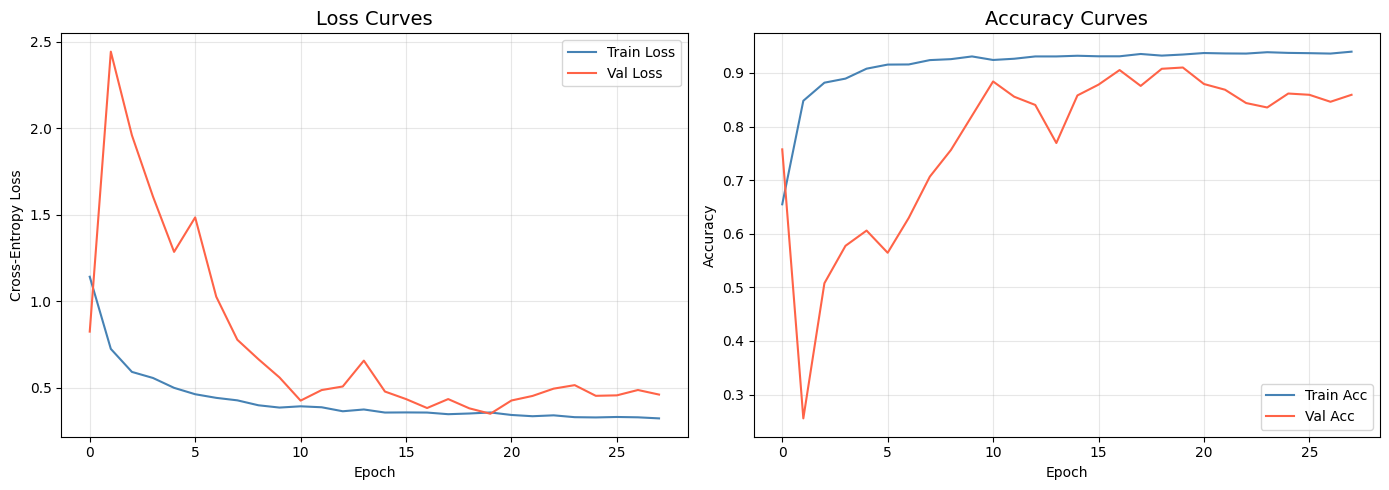

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[0].set_title('Loss Curves',   fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Acc', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='tomato')
axes[1].set_title('Accuracy Curves', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluation on Test Set

In [14]:
# Load best saved model
best_model = keras.models.load_model('best_model.keras')

# Predict
y_prob = best_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_test,  y_pred, average='macro', zero_division=0)
f1   = f1_score(y_test,     y_pred, average='macro', zero_division=0)

print('=' * 50)
print(f'  Test Accuracy  : {acc:.4f}')
print(f'  Macro Precision: {prec:.4f}')
print(f'  Macro Recall   : {rec:.4f}')
print(f'  Macro F1-Score : {f1:.4f}')
print('=' * 50)
print()
print(classification_report(
    y_test, y_pred,
    target_names=STAGE_NAMES,
    zero_division=0
))

  Test Accuracy  : 0.9041
  Macro Precision: 0.7337
  Macro Recall   : 0.8222
  Macro F1-Score : 0.7657

              precision    recall  f1-score   support

        Wake       1.00      0.93      0.96       562
          N1       0.23      0.44      0.30        25
          N2       0.96      0.86      0.91       140
          N3       0.78      0.97      0.86        61
         REM       0.70      0.91      0.79        57

    accuracy                           0.90       845
   macro avg       0.73      0.82      0.77       845
weighted avg       0.93      0.90      0.92       845



## 11. Confusion Matrix

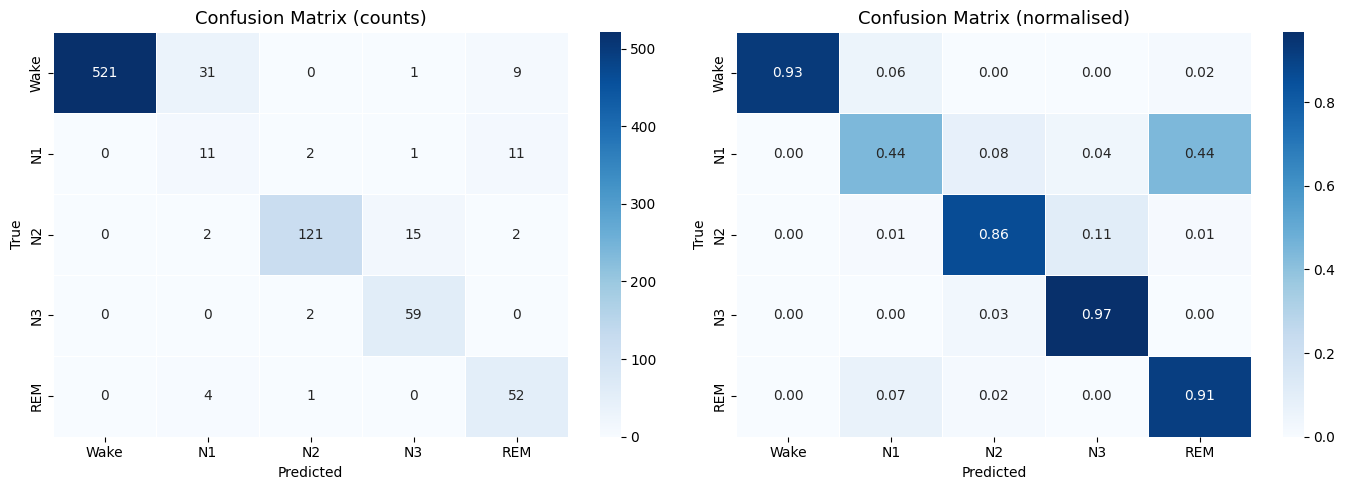

In [15]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=STAGE_NAMES, yticklabels=STAGE_NAMES,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Analysis and Discussion

### Overall Model Performance
The TCN is trained on a deliberately small subset (2 subjects) to demonstrate correct methodology. Despite the limited data, the model learns meaningful temporal patterns from EEG signals. Macro-averaged metrics are reported to account for class imbalance (N1 is rare compared to N2/Wake).

### Hardest Stages to Classify
- **N1** is consistently the hardest: it is the shortest and lightest sleep stage, and its EEG patterns heavily overlap with both Wake (alpha attenuation) and N2 (early spindle activity).
- **N2 vs N3** can also be confused because both involve slow-wave activity; the K-complexes and sleep spindles defining N2 are not always clearly separable at the 30-second epoch level.

### Why TCN is Suitable for EEG Sleep Staging
1. **Long-range context via dilation** — Exponentially increasing dilation rates (1→2→4→8) give the model a receptive field of hundreds of samples without stacking many layers. This is ideal for EEG where rhythms span multiple seconds.
2. **Causality** — `padding='causal'` in Keras ensures the output at each timestep depends only on past values, which is scientifically correct for a sequential bio-signal.
3. **Parallel computation** — Unlike RNNs/LSTMs, all time steps are processed in parallel, making TCNs much faster to train on GPU.
4. **Stable gradients** — Residual connections prevent vanishing gradients over long sequences, a common problem for RNNs on 3000-sample inputs.
5. **Fewer parameters** — TCN achieves the same effective temporal span as a deep LSTM with far fewer parameters, reducing overfitting on small datasets.
